In [1]:
!wget -nc https://lazyprogrammer.me/course_files/AirlineTweets.csv

--2025-05-22 11:25:04--  https://lazyprogrammer.me/course_files/AirlineTweets.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3030::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3421431 (3.3M) [text/csv]
Saving to: ‘AirlineTweets.csv’

AirlineTweets.csv   100%[===================>]   3.26M  13.0MB/s    in 0.3s    

2025-05-22 11:25:05 (13.0 MB/s) - ‘AirlineTweets.csv’ saved [3421431/3421431]



In [39]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv("../datasets/AirlineTweets.csv")
df.head(5)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


<Axes: >

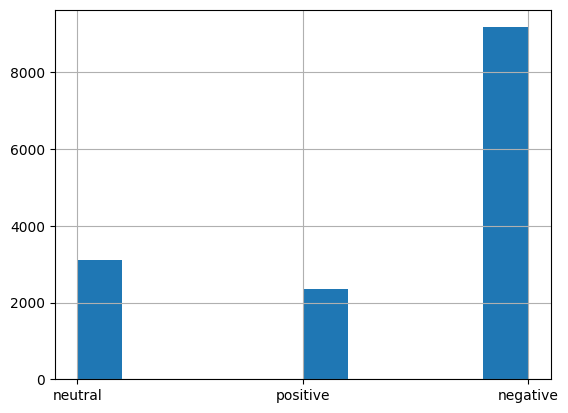

In [ ]:
df = df[['airline_sentiment', 'text']]
df['airline_sentiment'].hist()

In [10]:
target_map = {'positive': 1, 'negative': 0, 'neutral': 2}
df['target'] = df['airline_sentiment'].map(target_map)

In [11]:
df_train, df_test = train_test_split(df)

In [14]:
vectorizer = TfidfVectorizer(max_features=2000)

X_train = vectorizer.fit_transform(df_train['text'])
X_test = vectorizer.transform(df_test['text'])
Y_train = df_train['target']
Y_test = df_test['target']

In [21]:
model = LogisticRegression(max_iter = 500, penalty= "l2")
model.fit(X_train, Y_train)

print("Train acc:", model.score(X_train, Y_train))
print("Test acc:", model.score(X_test, Y_test))

Train acc: 0.8542805100182149
Test acc: 0.8043715846994536


In [ ]:
Pr_train = model.predict_proba(X_train)#[:, 1]
Pr_test = model.predict_proba(X_test)#[:, 1]

print("Train AUC:", roc_auc_score(Y_train, Pr_train, multi_class='ovo'))
print("Test AUC:", roc_auc_score(Y_test, Pr_test, multi_class='ovo'))

Train AUC: 0.9414041352226844
Test AUC: 0.8975998776732795


In [23]:
P_train = model.predict(X_train)
P_test = model.predict(X_test)

cm = confusion_matrix(Y_train, P_train, normalize='true')
cm

array([[0.96143211, 0.00771358, 0.03085432],
       [0.18586089, 0.71493729, 0.09920182],
       [0.31125265, 0.0433121 , 0.64543524]])

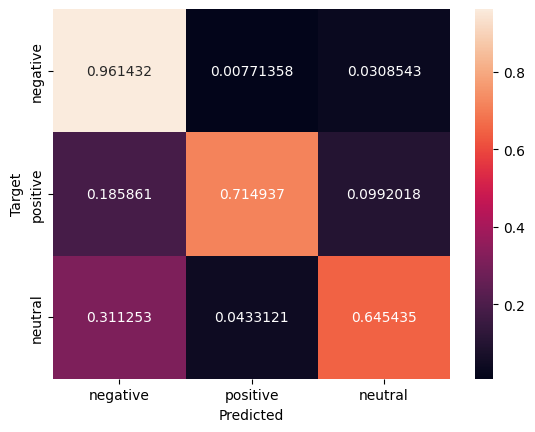

In [29]:
def plot_cm(cm):
    classes = ["negative", "positive", "neutral"]
    df_cm = pd.DataFrame(cm, index = classes, columns = classes)
    ax = sn.heatmap(df_cm, annot = True, fmt = "g")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Target")

plot_cm(cm)

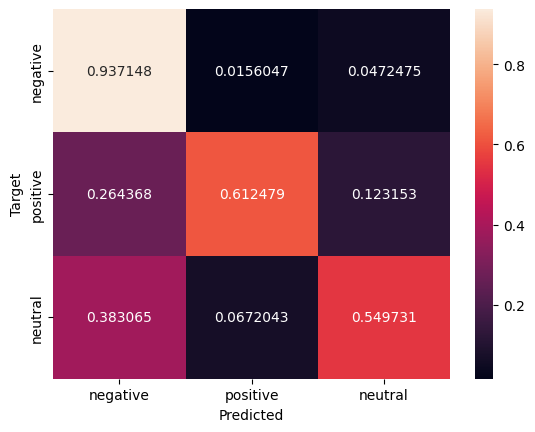

In [30]:
cm_test = confusion_matrix(Y_test, P_test, normalize='true')
plot_cm(cm_test)

##### Binary Labels and Model Interpretation

In [31]:
binary_target_list = [target_map['positive'], target_map['negative']]
df_b_train = df_train[df_train['target'].isin(binary_target_list)]
df_b_test = df_test[df_test['target'].isin(binary_target_list)]

In [34]:
X_train = vectorizer.fit_transform(df_b_train['text'])
X_test = vectorizer.transform(df_b_test['text'])

Y_train = df_b_train['target']
Y_test = df_b_test['target']


In [35]:
model = LogisticRegression(max_iter=500)
model.fit(X_train, Y_train)
print("Train acc:", model.score(X_train, Y_train))
print("Test acc:", model.score(X_test, Y_test))

Train acc: 0.9312463768115942
Test acc: 0.9094650205761317


In [36]:
Pr_train = model.predict_proba(X_train)[:, 1]
Pr_test = model.predict_proba(X_test)[:, 1]
print("Train AUC:", roc_auc_score(Y_train, Pr_train))
print("Test AUC:", roc_auc_score(Y_test, Pr_test))

Train AUC: 0.9786816154422259
Test AUC: 0.9494356790890579


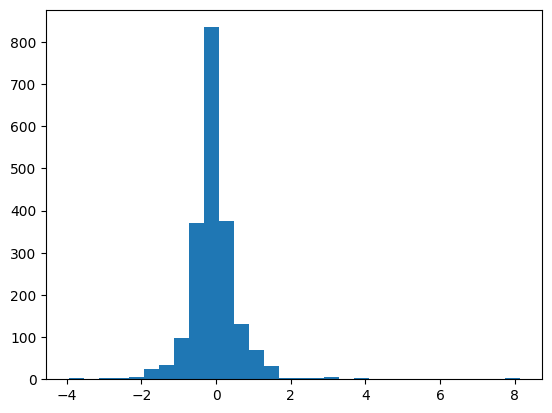

In [41]:
plt.hist(model.coef_[0], bins=30)
plt.show()

In [42]:
word_index_map = vectorizer.vocabulary_

In [45]:
threshold = 2

print("Most positive words:")
for word, index in word_index_map.items():
    weight = model.coef_[0][index]
    if weight > threshold:
        print(word, weight)

Most positive words:
southwestair 3.053977880071835
jetblue 3.4391952623947466
thank 7.954442337110116
thanks 8.128357111918584
virginamerica 3.209606705103882
best 3.7621275875615012
love 4.598540441813473
great 5.53527951505557
excellent 2.5877670594052518
nice 2.101953420405099
appreciate 2.7545016893555574
kudos 2.2390865869554033
worries 3.029161978357411
awesome 4.242610012307361
amazing 3.763663401394902
good 3.01705903798281
thx 2.9034936258032027


In [46]:
threshold = -2

print("Most negative words:")
for word, index in word_index_map.items():
    weight = model.coef_[0][index]
    if weight < threshold:
        print(word, weight)

Most negative words:
not -3.9507448273251744
no -3.9288026565540113
cancelled -2.8343083246031555
hold -2.6130200696354113
is -2.0254888520659295
hour -2.1555833639573403
why -2.1900679455808114
worst -3.0729058343803826
nothing -2.238223537640623
delayed -2.6966555924992424
website -2.150576664052103
hours -3.110426455892492


In [61]:
threshold = 0.999

for idx, tweet in enumerate(Pr_test):
    if tweet > threshold:
        print(df.iloc[idx].text)
    


@VirginAmerica twitter team. you guys killed it for rescheduling me asap. thank you!
@united So they didn't drop my bag overnight &amp; now I'm leaving for a week. This is why you were supposed to hold on to the bag....
@united did your super computer 💩 ots pants? Lots of cranky people in line at CMH reFlight Booking Problems, delaying check-ins of on-time, direct flyers
@united that's not an apology. Say it.
@united remember in business, a pleasant experience, means you will tell a friend. A bad experience means you will tell everyone you see
